In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("malaychand/coco-25-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 185M/185M [00:12<00:00, 15.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1):
['classification']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'classification', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'classification', 'test'))}")

Contents of the 'train' directory: ['couch', 'potted plant', 'stop sign', 'airplane', 'pizza', 'truck', 'traffic light', 'cow', 'bicycle', 'train', 'bottle', 'car', 'bird', 'motorcycle', 'bench', 'elephant', 'dog', 'cat', 'cake', 'chair', 'horse', 'cup', 'bus', 'bowl', 'person']
Contents of the 'test' directory: ['couch', 'potted plant', 'stop sign', 'airplane', 'pizza', 'truck', 'traffic light', 'cow', 'bicycle', 'train', 'bottle', 'car', 'bird', 'motorcycle', 'bench', 'elephant', 'dog', 'cat', 'cake', 'chair', 'horse', 'cup', 'bus', 'bowl', 'person']



--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/train) ---
Found 5250 images in /root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/train. Displaying 6 samples:


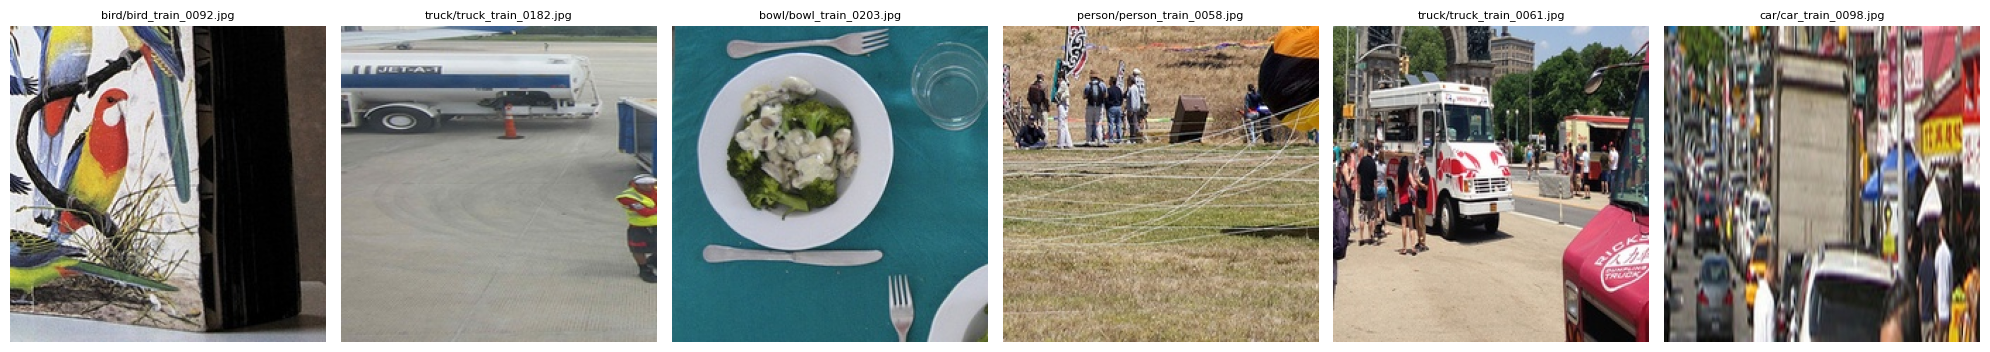


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/test) ---
Found 750 images in /root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/test. Displaying 6 samples:


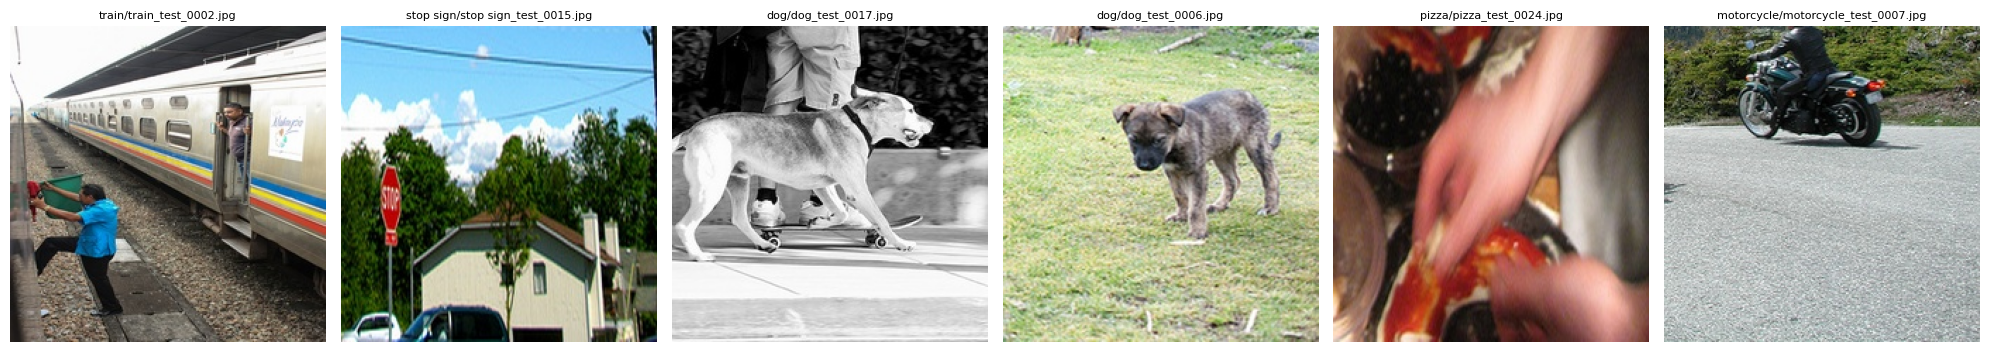

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'classification' subdirectory
train_path = os.path.join(path, 'classification', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'classification', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Optionally set memory growth to avoid allocating all memory at once
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU found. Training will proceed on CPU (not recommended for Inception).")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, optimizers

# Hyperparameters
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 25

# Data Preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Model Building
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze base model layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_loss' if NUM_CLASSES == 2 else 'categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Found 4200 images belonging to 25 classes.
Found 1050 images belonging to 25 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Starting training...
Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.3788 - loss: 2.3025 - val_accuracy: 0.5657 - val_loss: 1.5667
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 119s 900ms/step - accuracy: 0.5438 - loss: 1.5813 - val_accuracy: 0.6162 - val_loss: 1.3442
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 117s 886ms/step - accuracy: 0.5919 - loss: 1.4201 - val_accuracy: 0.6286 - val_loss: 1.2638
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 116s 876ms/step - accuracy: 0.6176 - loss: 1.2992 - val_accuracy: 0.6486 - val_loss: 1.2143
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 114s 867ms/step - accuracy: 0.6450 - loss: 1.2298 - val_accuracy: 0.6705 - val_loss: 1.1499
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 117s 887ms/step - accuracy: 0.6588 - loss: 1.1576 - val_accuracy: 0.6619 - val_loss: 1.1645
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 115s 876ms/st

In [ ]:
# Evaluate on test set
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Summary of training
print("\n--- Training Summary ---")
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

Found 750 images belonging to 25 classes.
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 486ms/step - accuracy: 0.7147 - loss: 0.9819
Test Loss: 0.9819
Test Accuracy: 0.7147

--- Training Summary ---
Final Training Accuracy: 0.6883
Final Validation Accuracy: 0.6905


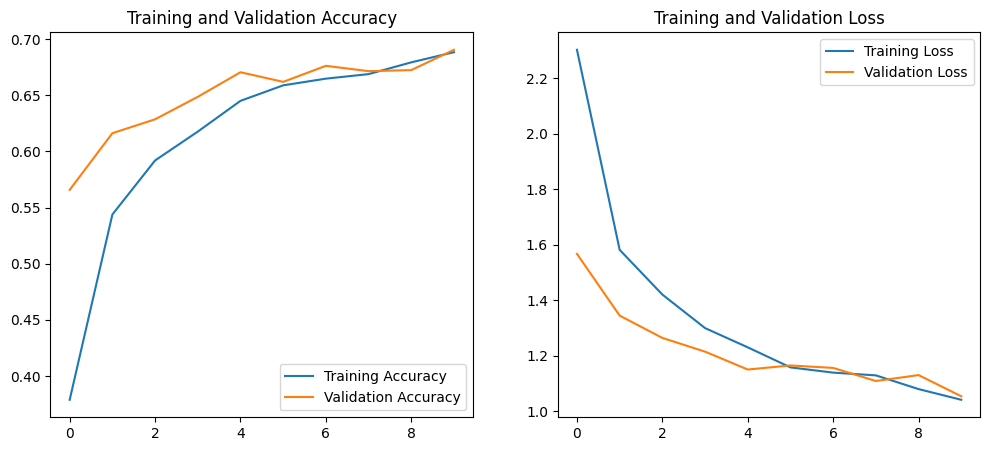

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')

    plt.show()

plot_history(history)